In [3]:
import pandas as pd
import numpy as np

In [4]:
# Veriyi df_makro adlı bir değişkene okut.
df_makro = pd.read_csv("makro_veri.csv")
print(df_makro)



        Tarih  Enflasyon  Faiz
0  2026-01-31        4.5   4.0
1  2026-02-28        4.2   4.5
2  2026-03-31        4.0   4.5
3  2026-04-30        4.6   4.5
4  2026-05-31        4.1   5.0
5  2026-06-30        3.8   5.0


In [5]:
# 1.Adım: Altyapı ve Zaman Serisi (Görevler)

# "Tarih" sütununu pd.to_datetime() ile gerçek zaman formatına çevir.
df_makro["Tarih"] = pd.to_datetime(df_makro["Tarih"])
#"Tarih" sütununu .set_index() ile tablonun satır başı (indeksi) yap.
df_makro = df_makro.set_index("Tarih")
print(df_makro)


            Enflasyon  Faiz
Tarih                      
2026-01-31        4.5   4.0
2026-02-28        4.2   4.5
2026-03-31        4.0   4.5
2026-04-30        4.6   4.5
2026-05-31        4.1   5.0
2026-06-30        3.8   5.0


In [6]:
# 2.Adım: Matematiksel Operasyonlar (Görevler)

# Geçmişe Bakış: "Onceki_Enflasyon" adında bir sütun yarat ve "Enflasyon" sütununun 1 satır aşağı kaydırılmış halini (.shift(1)) buraya ata.
df_makro["Onceki_Enflasyon"] = df_makro["Enflasyon"].shift(1)
# Hareketli Ortalama: "Faiz_SMA_3" adında bir sütun yarat ve "Faiz" sütununun 3 aylık hareketli ortalamasını (.rolling(window=3).mean()) alıp .round(2) ile yuvarla.
df_makro["Faiz_SMA_3"] = df_makro["Faiz"].rolling(window=3).mean().round(2)
print(df_makro)


            Enflasyon  Faiz  Onceki_Enflasyon  Faiz_SMA_3
Tarih                                                    
2026-01-31        4.5   4.0               NaN         NaN
2026-02-28        4.2   4.5               4.5         NaN
2026-03-31        4.0   4.5               4.2        4.33
2026-04-30        4.6   4.5               4.0        4.50
2026-05-31        4.1   5.0               4.6        4.67
2026-06-30        3.8   5.0               4.1        4.83


In [7]:
# 3.Adım: Karar Motoru (Görevler)

# Merkez Bankası'nın duruşunu analiz edeceğiz. np.where() kullanarak "Politika_Durumu" adında yeni bir sütun aç.
# Koşul: Eğer o ayki "Faiz", "Enflasyon"dan BÜYÜKSE, tabloya "SIKI" (Sıkı Para Politikası) yaz, değilse "GEVSEK" yaz.
df_makro["Politika_Durumu"] = np.where(df_makro["Faiz"] > df_makro["Enflasyon"], "SIKI" , "GEVSEK")
print(df_makro)

            Enflasyon  Faiz  Onceki_Enflasyon  Faiz_SMA_3 Politika_Durumu
Tarih                                                                    
2026-01-31        4.5   4.0               NaN         NaN          GEVSEK
2026-02-28        4.2   4.5               4.5         NaN            SIKI
2026-03-31        4.0   4.5               4.2        4.33            SIKI
2026-04-30        4.6   4.5               4.0        4.50          GEVSEK
2026-05-31        4.1   5.0               4.6        4.67            SIKI
2026-06-30        3.8   5.0               4.1        4.83            SIKI


In [8]:
# 4.Adım: Temizlik ve Raporlama (Görevler)

# Tablodaki hesaplanamamış boş satırlardan kurtulmak için tabloyu .dropna() ile temizleyip kalıcı olarak kendine eşitle.
df_makro = df_makro.dropna()
# En alta in, .value_counts() kullanarak "Politika_Durumu" sütununda Merkez Bankası'nın kaç ay "SIKI", kaç ay "GEVSEK" politika izlediğini saydır ve ekrana yazdır. (Sayım sonucunun altında veya üstünde print(df_makro) ile tablonun son halini de görmeyi unutma).
ozet_rapor = df_makro["Politika_Durumu"].value_counts()
print(df_makro)

            Enflasyon  Faiz  Onceki_Enflasyon  Faiz_SMA_3 Politika_Durumu
Tarih                                                                    
2026-03-31        4.0   4.5               4.2        4.33            SIKI
2026-04-30        4.6   4.5               4.0        4.50          GEVSEK
2026-05-31        4.1   5.0               4.6        4.67            SIKI
2026-06-30        3.8   5.0               4.1        4.83            SIKI


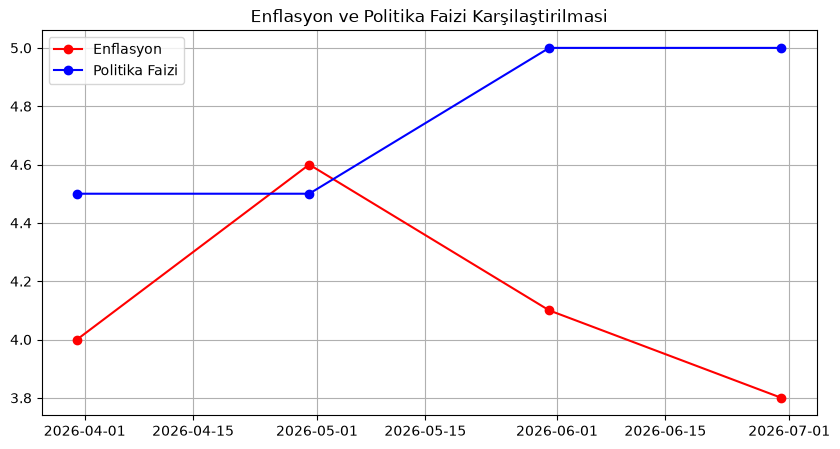

In [9]:
# Mantık Dersi 10: Matplotlib ile Grafik Çizimi

# Bir grafik oluşturmak, boş bir tuvale resim çizmek gibidir. İşlemler sırayla yapılır:
# 1.Tuvali Hazırla: Grafiğin boyutunu belirlersin (plt.figure(figsize=(genişlik, yükseklik))).
# 2.Çizgileri Çek: Hangi verilerin çizileceğini söylersin (plt.plot(x_ekseni, y_ekseni)).
# 3.Makyaj Yap: Başlık ekle, eksenleri isimlendir, ızgara (grid) koy.
# 4.Tabloyu Sergile: Grafiği ekrana bas (plt.show()).


# Görev (Sıra Sende): Görsel Makroekonomi Paneli

# Yeni bir kod hücresi aç ve en üste şu kütüphaneyi dahil et:
# import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# Hemen altına plt.figure(figsize=(10, 5)) yazarak 10'a 5 boyutlarında geniş bir tuval aç.
plt.figure(figsize=(10, 5))

# İlk çizgimizi (Enflasyon) çiziyoruz. X ekseninde tarihler (yani tablomuzun indeksi), Y ekseninde ise enflasyon olacak.
# Şu kodu mantığını kavrayarak yaz:
# (Not: marker="o" komutu, her bir ayın veri noktasına yuvarlak bir işaret koyar).
# plt.plot(df_makro.index, df_makro["Enflasyon"], label="Enflasyon", color="red", marker="o")
plt.plot(df_makro.index, df_makro["Enflasyon"], label="Enflasyon", color="red", marker="o")

# Hemen altına ikinci çizgimizi (Faiz) çiz.
# Yukarıdaki kodun aynısını kullan ama sütun adını "Faiz", rengini "blue" ve etiketini (label) "Politika Faizi" olarak değiştir.
plt.plot(df_makro.index, df_makro["Faiz"], label="Politika Faizi", color="blue", marker="o")

# Grafiğin makyajını yapalım. Sırasıyla şu üç komutu alt alta ekle:
# plt.title("Enflasyon ve Politika Faizi Karşılaştırması")
# plt.legend() (Bu, sağ üste 'kırmızı çizgi enflasyondur' diyen o küçük bilgi kutusunu ekler)
# plt.grid(True) (Arka plana okunabilirliği artıran ızgaralar çizer)
plt.title("Enflasyon ve Politika Faizi Karşilaştirilmasi")
plt.legend()
plt.grid(True)

# En alta plt.show() yaz ve hücreyi çalıştır.
plt.show()




In [14]:
# Mantık Dersi 11: Tabloları Kaynatmak (pd.merge)
# İki farklı tabloyu, içlerindeki ortak bir sütuna (örneğin "Tarih" veya "Müşteri_ID") bakarak fermuar gibi birbirine dikmek için pd.merge() aracını kullanırız.
# Kalıp şudur: yeni_tablo = pd.merge(sol_tablo, sag_tablo, on="Ortak_Sutun_Adi")

# Görev (Sıra Sende): Tabloları Birleştirme
# Hemen alta yeni bir kod hücresi aç ve sanki TÜİK'ten gelmiş gibi ikinci bir veri tablosu (df_issizlik) oluştur. Şu kodu doğrudan kullanabilirsin:

# 1. Yeni veriyi oluşturuyoruz ve tarihleri Pandas'a öğretiyoruz
veri = {"Tarih": ["2026-04-30", "2026-05-31", "2026-06-30"], "Issizlik": [10.2, 10.5, 10.8]}
df_issizlik = pd.DataFrame(veri)
df_issizlik["Tarih"] = pd.to_datetime(df_issizlik["Tarih"])


# Ana tablomuz (df_makro) şu an tarihleri indeks (satır başı) olarak tutuyor.
# İki tabloyu "Tarih" sütunu üzerinden birleştirebilmemiz için
# ana tablodaki o indeksi tekrar normal bir sütun haline getirmemiz (sıfırlamamız) gerekir. Alt satıra şu komutu yaz:
# df_makro = df_makro.reset_index()
df_makro = df_makro.reset_index()

# Şimdi birleştirme operasyonu:
# Öğrendiğin pd.merge() kalıbını kullanarak
# df_makro ile df_issizlik tablolarını "Tarih" sütunu üzerinden birleştir ve birlesik_tablo adında yepyeni bir değişkene ata.

birlesik_tablo = pd.merge(df_makro, df_issizlik, on="Tarih")
print(birlesik_tablo)

   index      Tarih  Enflasyon  Faiz  Onceki_Enflasyon  Faiz_SMA_3  \
0      1 2026-04-30        4.6   4.5               4.0        4.50   
1      2 2026-05-31        4.1   5.0               4.6        4.67   
2      3 2026-06-30        3.8   5.0               4.1        4.83   

  Politika_Durumu  Issizlik  
0          GEVSEK      10.2  
1            SIKI      10.5  
2            SIKI      10.8  


In [18]:
# Aşama 3: İstatistiksel Analiz ve Modelleme.

# Şu ana kadar veriyi çektik, temizledik ve grafiklere döktük.
# Ancak bir ekonometrist sadece grafiğe bakarak "faiz artınca enflasyon düşmüş gibi duruyor" demez.
# Bunu matematiksel olarak kanıtlamak zorundadır.
# Bu kanıtı sunan en temel araç EKK (En Küçük Kareler) veya İngilizce adıyla OLS (Ordinary Least Squares) regresyon modelidir. 

# Mantık Dersi 12: Regresyon (Sebep-Sonuç İlişkisi)
# Regresyon analizi:
# bir bağımlı değişken ile bir veya daha fazla bağımsız değişken arasındaki ilişkiyi ölçmek ve 
# geleceğe yönelik tahminler yapmak için kullanılan bir istatistiksel yöntemdir.
# Regresyon, iki değişken arasında gerçekten istatistiksel bir ilişki olup olmadığını ölçer.
# Teorik denklemimiz Y = beta_0 + beta_1*X + epsilon şeklindedir.
# Burada $Y$ etkilenen (bağımlı), $X$ ise etkileyen (bağımsız) değişkendir.

# Python'da ekonometrik modeller kurmak için statsmodels kütüphanesini kullanırız. Çalışma mantığı 4 adımdan oluşur:
# Etkilenen değişkeni (Y) ve etkileyen değişkeni (X) seçmek.
# X'in yanına bir sabit sayı (beta_$) eklemek (Modelin başlangıç noktası).
# Modeli kurup veriyi içine oturtmak (fit()).
# Çıkan istatistiksel özet tablosunu okumak.
# Şimdi bu mantıkla;
# senin hazırladığın o birlesik_tablo üzerinden faizin enflasyonu nasıl etkilediğini ölçeceğimiz ilk OLS modelini kurma sırası sende.

# Görev (Sıra Sende): OLS Regresyon Modeli

# Yeni bir kod hücresi aç ve ekonometri kütüphanemizi çağır:
# import statsmodels.api as sm

import statsmodels.api as sm

# Hangi değişkenin kimi etkilediğini tanımlayalım. Y (Bağımlı) enflasyon olsun, X (Bağımsız) faiz olsun. Şunları yaz:
Y = birlesik_tablo["Enflasyon"]
X = birlesik_tablo["Faiz"]

# Ekonometrik modelin doğru çalışması için formüldeki sabiti (beta_0) eklememiz şarttır. X'i şu komutla güncelle:
X = sm.add_constant(X)

# Modeli kurup çalıştırıyoruz (fit komutu "çizgiyi çek ve hesapla" demektir):
model = sm.OLS(Y, X).fit()

# Son olarak ekonometristlerin en çok baktığı o meşhur sonuç raporunu ekrana yazdır:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Enflasyon   R-squared:                       0.862
Model:                            OLS   Adj. R-squared:                  0.724
Method:                 Least Squares   F-statistic:                     6.259
Date:                Fri, 02 Oct 2026   Prob (F-statistic):              0.242
Time:                        10:52:53   Log-Likelihood:                 2.0427
No. Observations:                   3   AIC:                          -0.08548
Df Residuals:                       1   BIC:                            -1.888
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.4500      2.514      4.156      0.1

c:\Users\Nacic\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 3 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
